# Market Simulation

## Libraries Import

In [8]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path


from scipy import stats
from scipy.optimize import brentq

sys.path.append('..')
from src.config_loader import load_config
from src.stochastic_engines import GBMModel, MertonJumpDiffusion
from src.analytics import bsm_price

config = load_config()

## Example Path Generation

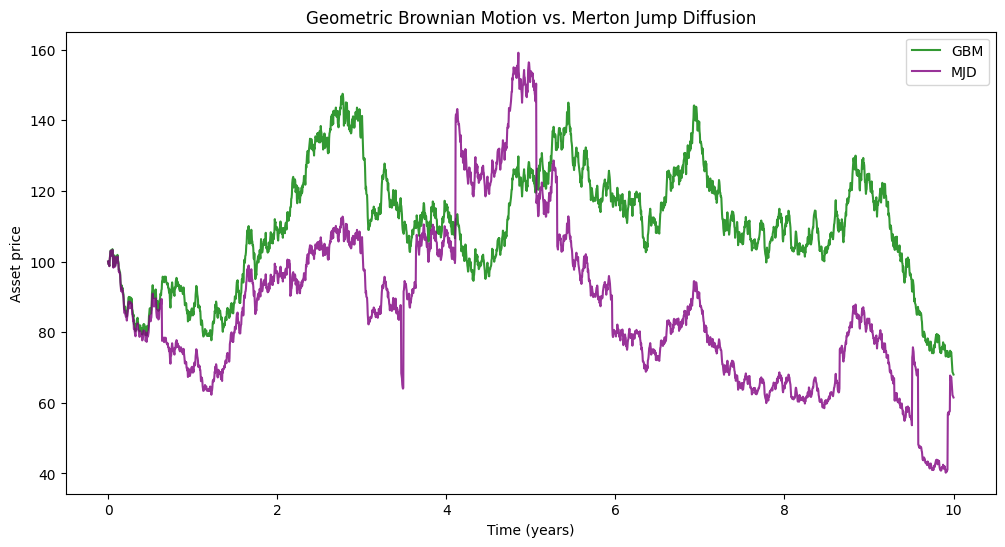

In [9]:
# Path generation
specific_seed = 67
config.simulation.seed = specific_seed
gbm = GBMModel(config).generate_paths()
merton = MertonJumpDiffusion(config).generate_paths()

paths_file = Path("..") / "data" / "simulated_paths.npz"
paths_file.parent.mkdir(parents=True, exist_ok=True)

calculated_dt = float(config.market_params.T) / int(config.market_params.n_steps)

np.savez_compressed(
    paths_file,
    gbm=gbm,
    merton=merton,
    dt=calculated_dt,
    n_steps=int(config.market_params.n_steps),
    T=float(config.market_params.T),
    S0=float(config.market_params.S0),
    n_paths=int(config.simulation.n_paths),
    seed=specific_seed
)

# Time grid
n_steps = config.market_params.n_steps
T = config.market_params.T
_t = np.linspace(0.0, T, n_steps + 1)

plt.figure(figsize=(12, 6))
plt.plot(_t, gbm[0, :], label='GBM', color='green', alpha=0.8)
plt.plot(_t, merton[0, :], label='MJD', color='purple', alpha=0.8)
plt.title("Geometric Brownian Motion vs. Merton Jump Diffusion")
plt.xlabel("Time (years)")
plt.ylabel("Asset price")
plt.legend()
plt.show()

## Monte Carlo Simulation

In [10]:
n_steps = gbm.shape[1] - 1
dt = config.market_params.T / n_steps
t = np.arange(n_steps + 1) * dt

def sample_paths(paths: np.ndarray, n_plot: int = 30, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n = paths.shape[0]
    idx = rng.choice(n, size=min(n_plot, n), replace=False)
    return paths[idx]

def log_returns(paths: np.ndarray) -> np.ndarray:
    return np.diff(np.log(paths), axis=1)

def terminal_log_returns(paths: np.ndarray) -> np.ndarray:
    return np.log(paths[:, -1] / paths[:, 0])

def var_cvar(x: np.ndarray, alpha: float = 0.99) -> tuple[float, float]:
    x = np.asarray(x)
    q = np.quantile(x, alpha)
    tail = x[x >= q]
    cvar = float(tail.mean()) if tail.size else float("nan")
    return float(q), cvar

def max_drawdown(paths: np.ndarray) -> np.ndarray:
    running_max = np.maximum.accumulate(paths, axis=1)
    dd = 1.0 - (paths / running_max)
    return dd.max(axis=1)

def realized_variance(r: np.ndarray) -> np.ndarray:
    return np.sum(r**2, axis=1)

def bipower_variation(r: np.ndarray) -> np.ndarray:
    abs_r = np.abs(r)
    return (np.pi / 2.0) * np.sum(abs_r[:, 1:] * abs_r[:, :-1], axis=1)

def implied_vol_from_price(price: float, S: float, K: float, T: float, r: float, option_type: str = 'call') -> float:
    if price <= 0:
        return float('nan')

    def f(sig: float) -> float:
        return bsm_price(S, K, T, r, sig, option_type=option_type) - price

    try:
        return float(brentq(f, 1e-6, 5.0, maxiter=200))
    except ValueError:
        return float('nan')

print(f"n_paths={gbm.shape[0]}, n_steps={n_steps}, dt={dt}, T≈{n_steps*dt:.4f}")

n_paths=10000, n_steps=2520, dt=0.003968253968253968, T≈10.0000


## Sample Path Diagnostics

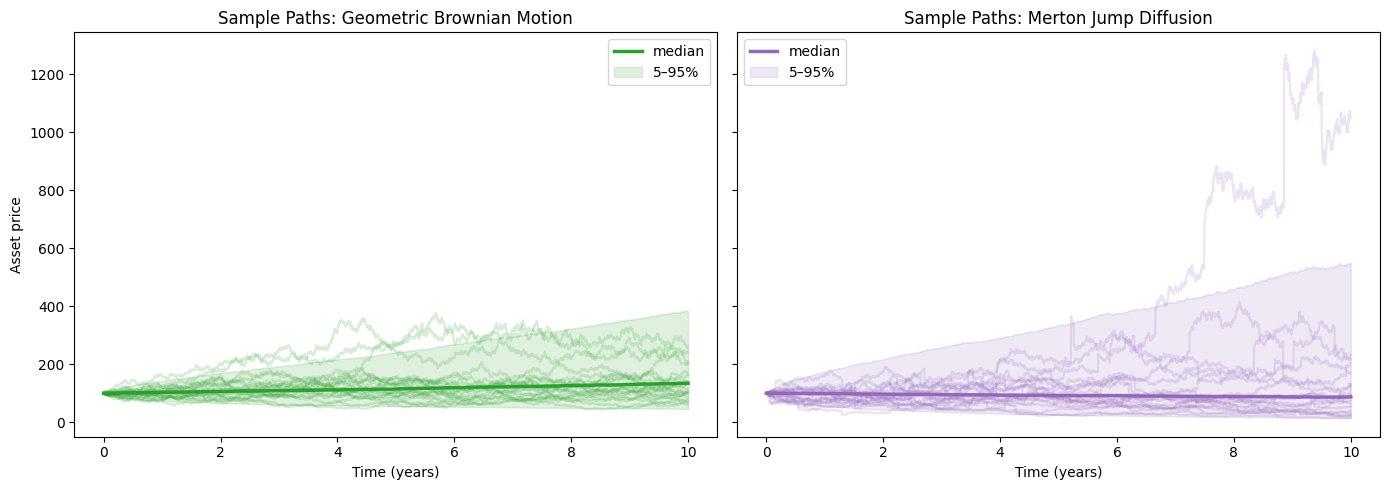

In [14]:
# Number of paths to plot
n_plot = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# GBM sample paths
for p in sample_paths(gbm, n_plot=n_plot, seed=config.simulation.seed + 1):
    axes[0].plot(t, p, color='tab:green', alpha=0.18)

q05, q50, q95 = np.quantile(gbm, [0.05, 0.5, 0.95], axis=0)
axes[0].plot(t, q50, color='tab:green', lw=2.5, label='median')
axes[0].fill_between(t, q05, q95, color='tab:green', alpha=0.15, label='5–95%')
axes[0].set_title('Sample Paths: Geometric Brownian Motion')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Asset price')
axes[0].legend()

# MJD sample paths
for p in sample_paths(merton, n_plot=n_plot, seed=config.simulation.seed + 2):
    axes[1].plot(t, p, color='tab:purple', alpha=0.18)

q05, q50, q95 = np.quantile(merton, [0.05, 0.5, 0.95], axis=0)
axes[1].plot(t, q50, color='tab:purple', lw=2.5, label='median')
axes[1].fill_between(t, q05, q95, color='tab:purple', alpha=0.15, label='5–95%')
axes[1].set_title('Sample Paths: Merton Jump Diffusion')
axes[1].set_xlabel('Time (years)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation

In [12]:
def _lag1_autocorr_per_row(r: np.ndarray) -> np.ndarray:
    x = r[:, 1:]
    y = r[:, :-1]
    x = x - x.mean(axis=1, keepdims=True)
    y = y - y.mean(axis=1, keepdims=True)
    num = np.sum(x * y, axis=1)
    den = np.sqrt(np.sum(x * x, axis=1) * np.sum(y * y, axis=1))
    out = np.divide(num, den, out=np.full_like(num, np.nan, dtype=float), where=(den > 0))
    return out


def hurst_rs(x: np.ndarray, min_chunk: int = 10, max_chunk: int | None = None, n_chunks: int = 12) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 2 * min_chunk:
        return float("nan")

    if max_chunk is None:
        max_chunk = max(min_chunk + 1, n // 4)

    # Log-spaced chunk sizes
    sizes = np.unique(np.round(np.exp(np.linspace(np.log(min_chunk), np.log(max_chunk), n_chunks))).astype(int))
    sizes = sizes[(sizes >= min_chunk) & (sizes <= max_chunk)]
    if sizes.size < 2:
        return float("nan")

    rs_vals = []
    n_vals = []
    for m in sizes:
        k = n // m
        if k < 2:
            continue
        xs = x[:k * m].reshape(k, m)
        mu = xs.mean(axis=1, keepdims=True)
        y = xs - mu
        z = np.cumsum(y, axis=1)
        R = z.max(axis=1) - z.min(axis=1)
        S = y.std(axis=1, ddof=1)
        rs = np.divide(R, S, out=np.full_like(R, np.nan, dtype=float), where=(S > 0))
        rs = rs[np.isfinite(rs)]
        if rs.size:
            rs_vals.append(np.log(rs.mean()))
            n_vals.append(np.log(m))

    if len(rs_vals) < 2:
        return float("nan")

    n_vals = np.asarray(n_vals)
    rs_vals = np.asarray(rs_vals)
    slope = np.polyfit(n_vals, rs_vals, deg=1)[0]
    return float(slope)


def var_es_from_losses(losses: np.ndarray, alpha: float) -> tuple[float, float]:
    losses = np.asarray(losses, dtype=float)
    losses = losses[np.isfinite(losses)]
    if losses.size == 0:
        return float("nan"), float("nan")
    var = float(np.quantile(losses, alpha))
    tail = losses[losses >= var]
    es = float(tail.mean()) if tail.size else float("nan")
    return var, es


def evaluate_paths(paths: np.ndarray, dt: float, T: float) -> dict:
    paths = np.asarray(paths, dtype=float)
    r = log_returns(paths)

    # Steps per year
    A = 1.0 / dt

    # Annualized mean and volatility
    mean_log_step = r.mean(axis=1)
    std_log_step = r.std(axis=1, ddof=1)
    ann_mean_log = A * mean_log_step
    ann_vol = np.sqrt(A) * std_log_step

    # Realized variance and volatility
    qv = realized_variance(r)
    realized_vol = np.sqrt(qv / T)
    qv_ann = qv / T

    # Drift
    drift = terminal_log_returns(paths) / T

    # Max drawdown
    mdd = max_drawdown(paths)

    # Skewness and kurtosis
    skew = stats.skew(r, axis=1, bias=False, nan_policy='omit')
    kurt_excess = stats.kurtosis(r, axis=1, fisher=True, bias=False, nan_policy='omit')

    # Autocorrelation
    acf1 = _lag1_autocorr_per_row(r)

    # Hurst exponent
    x = np.log(paths)
    hurst = np.array([hurst_rs(xi) for xi in x])

    # Terminal distribution for risk
    terminal_simple_ret = (paths[:, -1] / paths[:, 0]) - 1.0
    losses = -terminal_simple_ret

    return {
        "A": A,
        "log_returns": r,
        "terminal_simple_ret": terminal_simple_ret,
        "losses": losses,
        "annualized_mean_log": ann_mean_log,
        "annualized_mean_simple": np.expm1(ann_mean_log),
        "annualized_vol": ann_vol,
        "realized_vol": realized_vol,
        "drift": drift,
        "max_drawdown": mdd,
        "skewness": skew,
        "kurtosis_excess": kurt_excess,
        "autocorr_lag1": acf1,
        "hurst": hurst,
        "quadratic_variation": qv,
        "quadratic_variation_annualized": qv_ann,
    }


T = float(config.market_params.T)
n_steps = int(config.market_params.n_steps)
dt = T / n_steps

gbm_eval = evaluate_paths(gbm, dt=dt, T=T)
mjd_eval = evaluate_paths(merton, dt=dt, T=T)

# VaR/ES for different confidence levels
levels = [0.90, 0.95, 0.975, 0.99, 0.995]
var_es_rows = []
for a in levels:
    gbm_var, gbm_es = var_es_from_losses(gbm_eval["losses"], a)
    mjd_var, mjd_es = var_es_from_losses(mjd_eval["losses"], a)
    var_es_rows.append({"alpha": a, "GBM_VaR": gbm_var, "GBM_ES": gbm_es, "MJD_VaR": mjd_var, "MJD_ES": mjd_es})

var_es_df = pd.DataFrame(var_es_rows)

# Summary table
metrics = [
    "annualized_mean_simple",
    "annualized_vol",
    "realized_vol",
    "drift",
    "max_drawdown",
    "skewness",
    "kurtosis_excess",
    "autocorr_lag1",
    "hurst",
    "quadratic_variation_annualized",
]

summary = pd.DataFrame({
    "metric": metrics,
    "GBM_mean": [np.nanmean(gbm_eval[m]) for m in metrics],
    "GBM_median": [np.nanmedian(gbm_eval[m]) for m in metrics],
    "MJD_mean": [np.nanmean(mjd_eval[m]) for m in metrics],
    "MJD_median": [np.nanmedian(mjd_eval[m]) for m in metrics],
})

display(summary)
display(var_es_df)

,metric,GBM_mean,GBM_median,MJD_mean,MJD_median
0,annualized_mean_simple,0.031529,0.030164,-0.006075,-0.013496
1,annualized_vol,0.199975,0.199968,0.344009,0.342043
2,realized_vol,0.199984,0.199979,0.344011,0.342036
3,drift,0.028991,0.029718,-0.012223,-0.013588
4,max_drawdown,0.470555,0.455180,0.692831,0.701191
5,skewness,-0.000155,-0.000554,-0.032885,-0.125549
6,kurtosis_excess,0.000327,-0.004636,146.911783,137.253674
7,autocorr_lag1,0.000051,0.000064,-0.000399,-0.000343
8,hurst,1.005334,1.006303,1.010066,1.011076
9,quadratic_variation_annualized,0.040002,0.039992,0.120289,0.116989


,alpha,GBM_VaR,GBM_ES,MJD_VaR,MJD_ES
0,0.900,0.414711,0.557276,0.778665,0.860635
1,0.950,0.538973,0.638142,0.856722,0.905426
2,0.975,0.625302,0.695511,0.900978,0.932665
3,0.990,0.699191,0.749870,0.934834,0.954717
4,0.995,0.736263,0.781040,0.951154,0.966610


## Return Distribution and Tail Loss

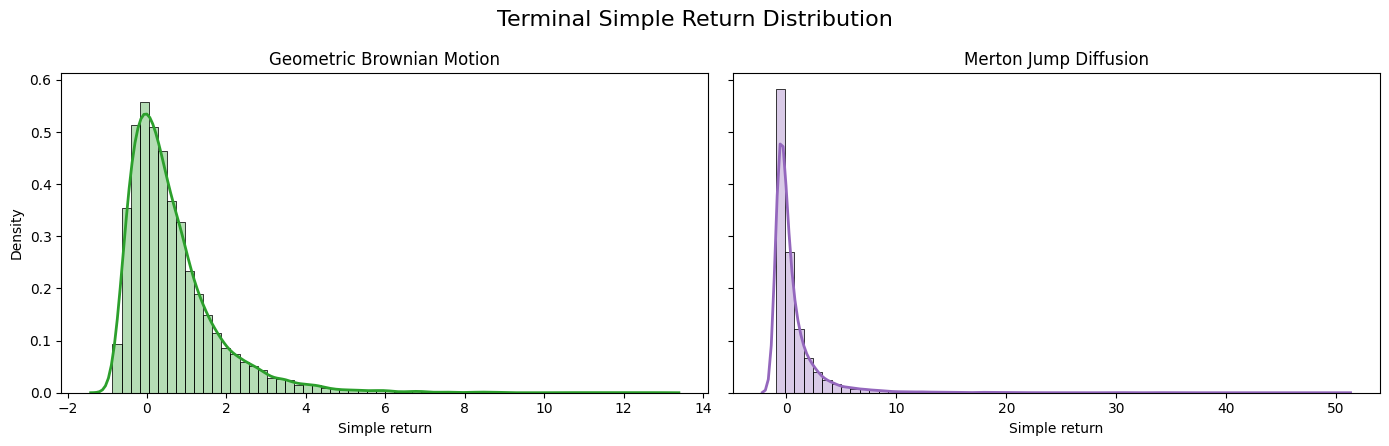

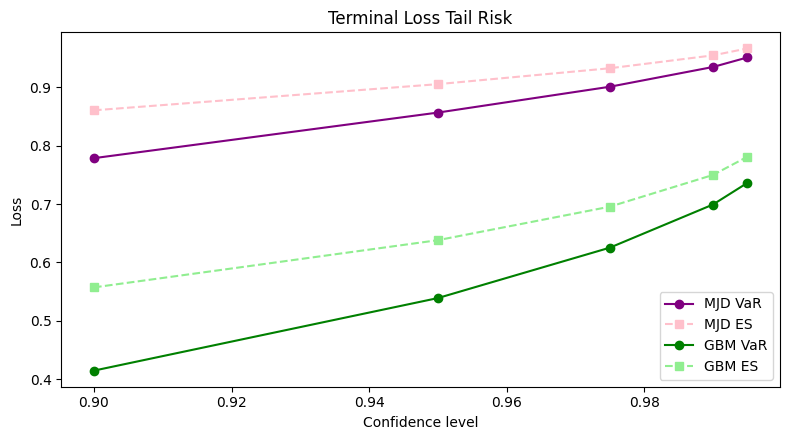

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

full_names = ["Geometric Brownian Motion", "Merton Jump Diffusion"]
for ax, (name, ev, color), full_name in zip(
    axes,
    [("GBM", gbm_eval, "tab:green"), ("MJD", mjd_eval, "tab:purple")], full_names
):
    ret = ev["terminal_simple_ret"]
    ret = ret[np.isfinite(ret)]
    sns.histplot(ret, bins=60, stat="density", ax=ax, color=color, alpha=0.35)
    sns.kdeplot(ret, ax=ax, color=color, lw=2)
    ax.set_title(full_name)
    ax.set_xlabel("Simple return")

plt.suptitle("Terminal Simple Return Distribution", fontsize=16)
plt.tight_layout()
plt.show()

# VaR and ES curves
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(var_es_df["alpha"], var_es_df["MJD_VaR"], marker="o", label="MJD VaR", color="purple")
ax.plot(var_es_df["alpha"], var_es_df["MJD_ES"], marker="s", ls="--", label="MJD ES", color="pink")
ax.plot(var_es_df["alpha"], var_es_df["GBM_VaR"], marker="o", label="GBM VaR", color="green")
ax.plot(var_es_df["alpha"], var_es_df["GBM_ES"], marker="s", ls="--", label="GBM ES", color="lightgreen")
ax.set_title("Terminal Loss Tail Risk")
ax.set_xlabel("Confidence level")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()